In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import  Dataset, DataLoader

In [3]:
torch.manual_seed(seed= 42)

In [4]:
df= pd.read_csv(r"/content/drive/MyDrive/dataset/fashion-mnist.csv")
df.head()


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
x= df.drop(columns= ['label'])
y= df['label']

In [6]:
x.head()

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


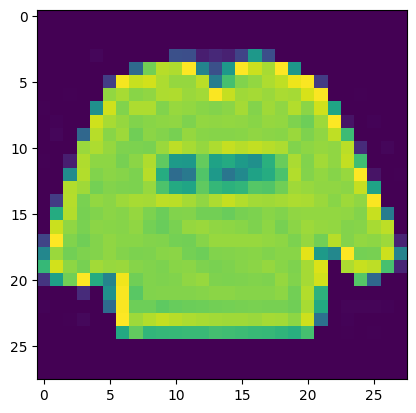

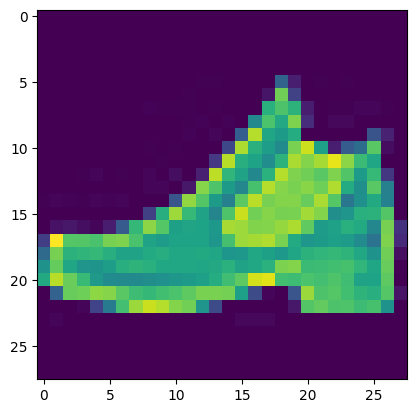

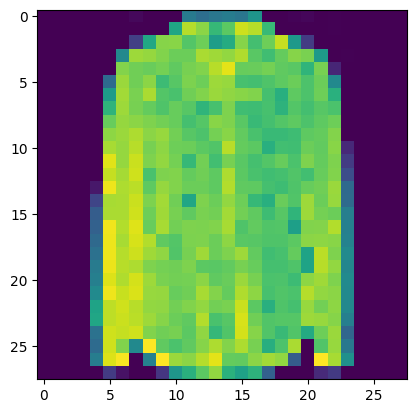

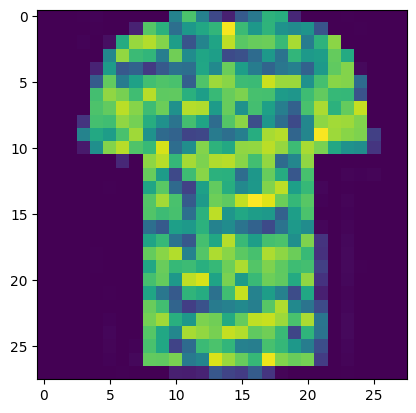

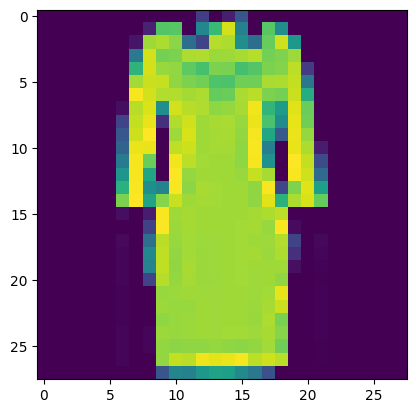

In [7]:
## visualixing numbers
for row in x.values[:5]:
    #plt.Figure(figsize=(5,5))
    plt.imshow(row.reshape(28,28))
    plt.show()

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x, y, random_state= 42, test_size= 0.2)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

scaler.fit(x_train)

x_train= scaler.transform(x_train)
x_test= scaler.transform(x_test)

In [10]:
x_train= torch.from_numpy(x_train).float()
x_test= torch.from_numpy(x_test).float()
y_train= torch.tensor(y_train.values, dtype= torch.long)
y_test= torch.tensor(y_test.values, dtype= torch.long)

In [11]:
device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features= features.reshape(-1, 1, 28, 28)
        self.labels= labels

    def __len__(self):
        return self.labels.shape[0]


    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [13]:
train_dataset= CustomDataset(x_train, y_train)
test_dataset= CustomDataset(x_test, y_test)

In [14]:
train_batch= DataLoader(dataset= train_dataset,
                        batch_size= 32,
                        pin_memory= True, shuffle= True)

In [15]:
test_batch= DataLoader(
    dataset= test_dataset,
    batch_size= 32,
    pin_memory= True,
    shuffle= True
)

In [16]:
class CNN(nn.Module):
    def __init__(self, num_img_channel, num_labels):

        super().__init__()

        self.cnn_part= nn.Sequential(

            nn.Conv2d(num_img_channel, 32, kernel_size= 3, padding='same'),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2, stride= 2),

            nn.Conv2d(32, 64, kernel_size= 3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2, stride= 2),
        )

        self.ann_part= nn.Sequential(

            nn.Flatten(),

            nn.Linear(64*7*7, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p= 0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p= 0.3),


            nn.Linear(64, num_labels)

        )


    def forward(self, data):
        self.result= self.cnn_part(data)
        self.result= self.ann_part(self.result)

        return self.result

In [17]:
cnn= CNN(1,df['label'].nunique())
cnn= cnn.to(device= device)

In [18]:
learning_rate= 1e-4
epoch= 50
regularization= 0.03

In [19]:
critetation= nn.CrossEntropyLoss()
optimizer= optim.Adam(params= cnn.parameters(),lr= learning_rate, weight_decay= regularization)

In [20]:
cnn.train()

CNN(
  (cnn_part): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (ann_part): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()


In [22]:
for i in range(epoch):
    total_loss= 0

    for batch_feature, batch_label in train_batch:
        batch_feature= batch_feature.to(device= device)
        batch_label= batch_label.to(device= device)


        y_pred= cnn(batch_feature)

        loss= critetation(y_pred, batch_label)

        
        total_loss+= loss.item()

        #reset all gradient
        optimizer.zero_grad()

        #calcn gradient
        loss.backward()

        #update trainable param
        optimizer.step()


    print(f"Epoch: {i+1}; loss: {total_loss/len(batch_label)}")



Epoch: 1; loss: 19.021892576944083
Epoch: 2; loss: 18.743370697833598
Epoch: 3; loss: 18.43086319649592
Epoch: 4; loss: 18.4255561651662
Epoch: 5; loss: 18.19718349678442
Epoch: 6; loss: 18.171058611012995
Epoch: 7; loss: 18.056024224031717
Epoch: 8; loss: 17.823331447318196
Epoch: 9; loss: 17.751114711165428
Epoch: 10; loss: 17.668260102160275
Epoch: 11; loss: 17.766509072855115
Epoch: 12; loss: 17.471591808833182
Epoch: 13; loss: 17.36960860621184
Epoch: 14; loss: 17.379955836571753
Epoch: 15; loss: 17.071666073519737
Epoch: 16; loss: 17.353035192005336
Epoch: 17; loss: 17.102619480807334
Epoch: 18; loss: 17.22596819885075
Epoch: 19; loss: 17.074725593440235
Epoch: 20; loss: 17.068999097682536
Epoch: 21; loss: 17.046921943780035
Epoch: 22; loss: 16.902658943552524
Epoch: 23; loss: 16.882375989109278
Epoch: 24; loss: 16.695199906360358
Epoch: 25; loss: 16.714018602855504
Epoch: 26; loss: 16.664660352747887
Epoch: 27; loss: 16.69943104404956
Epoch: 28; loss: 16.833261551801115
Epoch: 2

In [23]:
cnn.eval()

CNN(
  (cnn_part): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (ann_part): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()


In [28]:
accurate= 0
num= 0
for batch_features, batch_label in test_batch:
    batch_features= batch_features.to(device= device)
    batch_label= batch_label.to(device= device)
    
    with torch.no_grad():

        y_pred= cnn(batch_features)

    _, idx= torch.max(y_pred, dim= 1)

    corr= torch.where(
        idx== batch_label,
        1,
        0

    )

    accurate= accurate + corr.sum().item()
    num= num+ batch_label.shape[0]

print("Accuracy", accurate/num)



Accuracy 0.9161666666666667


In [29]:
#training loss
accurate= 0
num= 0
for batch_features, batch_label in train_batch:
    batch_features= batch_features.to(device= device)
    batch_label= batch_label.to(device= device)
    
    with torch.no_grad():

        y_pred= cnn(batch_features)

    _, idx= torch.max(y_pred, dim= 1)

    corr= torch.where(
        idx== batch_label,
        1,
        0

    )

    accurate= accurate + corr.sum().item()
    num= num+ batch_label.shape[0]

print("Accuracy", accurate/num)



Accuracy 0.9607291666666666
